# K-NN


In [18]:
import pandas as pd
from sklearn import neighbors
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder


In [21]:
# Carregar os arquivos
treino = pd.read_csv("tictactoe_treino.csv")
teste = pd.read_csv("tictactoe_teste.csv")
validacao = pd.read_csv("tictactoe_validacao.csv")


In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:

# lê cada um usando o nome do arquivo:
treino = pd.read_csv('tictactoe_treino.csv')
validacao = pd.read_csv('tictactoe_validacao.csv')
teste = pd.read_csv('tictactoe_teste.csv')

print('Treino:', treino.shape)
print('Validação:', validacao.shape)
print('Teste:', teste.shape)

print(treino.columns)

# Separa features e rótulos
X_treino = treino.drop('class', axis=1)
y_treino = treino['class']

X_validacao = validacao.drop('class', axis=1)
y_validacao = validacao['class']

X_teste = teste.drop('class', axis=1)
y_teste = teste['class']

print(X_treino.columns)



Treino: (1120, 10)
Validação: (320, 10)
Teste: (160, 10)
Index(['topLeft', 'topMid', 'topRight', 'midLeft', 'midMid', 'midRight',
       'botLeft', 'botMid', 'botRight', 'class'],
      dtype='object')
Index(['topLeft', 'topMid', 'topRight', 'midLeft', 'midMid', 'midRight',
       'botLeft', 'botMid', 'botRight'],
      dtype='object')


Mapeamento das saídas para inteiros:

In [24]:

encoder = LabelEncoder()
y_treino_encoded = encoder.fit_transform(y_treino)       # aprende + transforma
y_validacao_encoded = encoder.transform(y_validacao)      # só transforma
y_teste_encoded = encoder.transform(y_teste)              # só transforma



Mapeamento das entradas para inteiros:

In [25]:
# Define o mapeamento
simbolo_para_numero = {'x': 1, 'o': -1, 'b': 0}

# Aplica nos conjuntos
X_treino_encoded = X_treino.replace(simbolo_para_numero)
X_validacao_encoded = X_validacao.replace(simbolo_para_numero)
X_teste_encoded = X_teste.replace(simbolo_para_numero)


<ipython-input-25-411037c7ab6b>:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_treino_encoded = X_treino.replace(simbolo_para_numero)
<ipython-input-25-411037c7ab6b>:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_validacao_encoded = X_validacao.replace(simbolo_para_numero)
<ipython-input-25-411037c7ab6b>:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, s

Algoritmo Knn optimal:

In [26]:
clf = KNeighborsClassifier(n_neighbors=4)
clf.fit(X_treino_encoded, y_treino_encoded)



KNeighborsClassifier(n_neighbors=4)

Testando com vário k diferentes, para encontrar o valor ideal:

Testando vários valores de k...

k=1 | Acurácia: 0.8063 | Precision: 0.8021 | Recall: 0.8063 | F1: 0.8039 | Índice: 0.8046
k=2 | Acurácia: 0.8344 | Precision: 0.8524 | Recall: 0.8344 | F1: 0.8094 | Índice: 0.8326
k=3 | Acurácia: 0.8531 | Precision: 0.8486 | Recall: 0.8531 | F1: 0.8434 | Índice: 0.8496
k=4 | Acurácia: 0.8594 | Precision: 0.8672 | Recall: 0.8594 | F1: 0.8438 | Índice: 0.8574
k=5 | Acurácia: 0.8500 | Precision: 0.8592 | Recall: 0.8500 | F1: 0.8339 | Índice: 0.8483
k=6 | Acurácia: 0.8438 | Precision: 0.8528 | Recall: 0.8438 | F1: 0.8241 | Índice: 0.8411
k=7 | Acurácia: 0.8313 | Precision: 0.8327 | Recall: 0.8313 | F1: 0.8139 | Índice: 0.8273
k=8 | Acurácia: 0.8219 | Precision: 0.8246 | Recall: 0.8219 | F1: 0.7980 | Índice: 0.8166
k=9 | Acurácia: 0.8031 | Precision: 0.7949 | Recall: 0.8031 | F1: 0.7871 | Índice: 0.7971
k=10 | Acurácia: 0.7937 | Precision: 0.7897 | Recall: 0.7938 | F1: 0.7736 | Índice: 0.7877
k=11 | Acurácia: 0.8031 | Precision: 0.7972 | Recall: 0.8031 | F1:

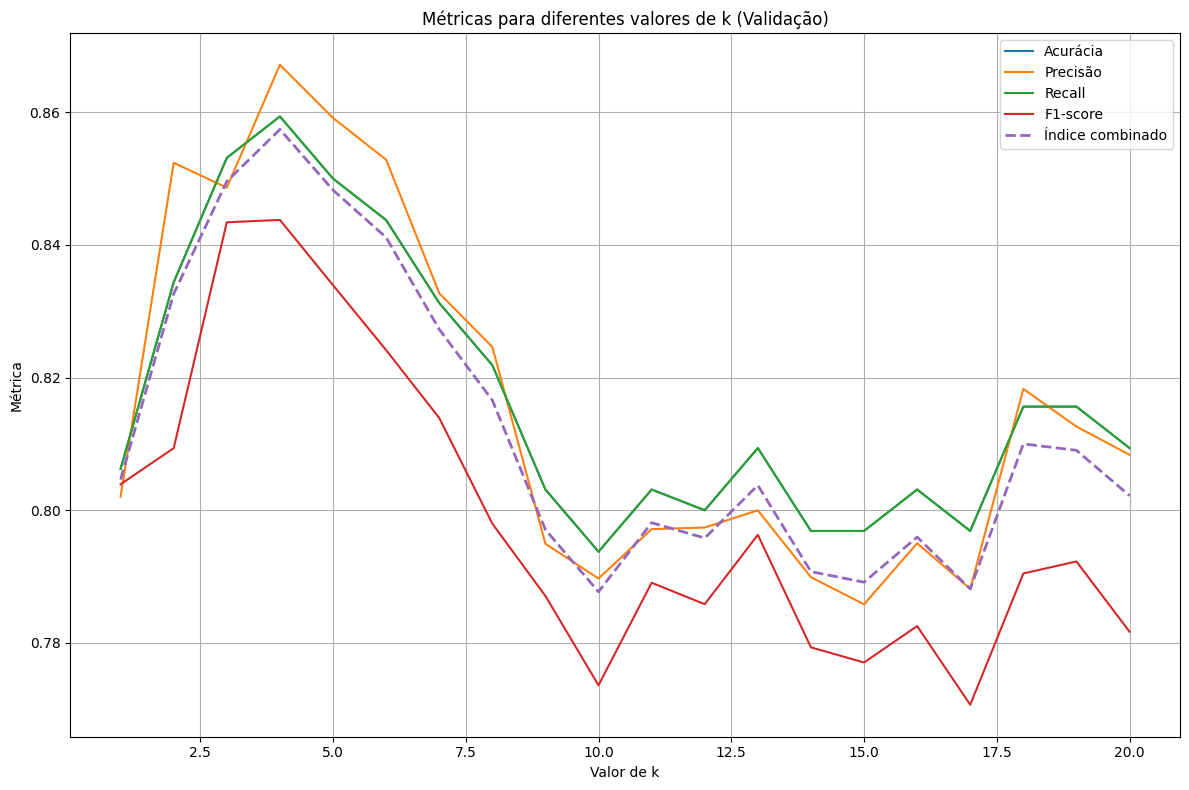

In [27]:
melhor_k = 1
melhor_indice = 0

# Listas para guardar os valores de cada métrica
k_values = []
acuracias = []
precisoes = []
recalls = []
f1s = []
indices = []

print("Testando vários valores de k...\n")

for k in range(1, 21):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_treino_encoded, y_treino_encoded)

    y_pred_validacao = clf.predict(X_validacao_encoded)

    acc = accuracy_score(y_validacao_encoded, y_pred_validacao)
    prec = precision_score(y_validacao_encoded, y_pred_validacao, average='macro')
    rec = recall_score(y_validacao_encoded, y_pred_validacao, average='macro')
    f1 = f1_score(y_validacao_encoded, y_pred_validacao, average='macro')

    indice_total = (acc + prec + rec + f1) / 4

    # Guardar valores nas listas
    k_values.append(k)
    acuracias.append(acc)
    precisoes.append(prec)
    recalls.append(rec)
    f1s.append(f1)
    indices.append(indice_total)

    print(f"k={k} | Acurácia: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | Índice: {indice_total:.4f}")

    if indice_total > melhor_indice:
        melhor_indice = indice_total
        melhor_k = k

print(f"\nMelhor k encontrado foi {melhor_k} com índice combinado de {melhor_indice:.4f}")

# Gerar gráfico
plt.figure(figsize=(12, 8))
plt.plot(k_values, acuracias, label='Acurácia')
plt.plot(k_values, precisoes, label='Precisão')
plt.plot(k_values, recalls, label='Recall')
plt.plot(k_values, f1s, label='F1-score')
plt.plot(k_values, indices, label='Índice combinado', linestyle='--', linewidth=2)

plt.title('Métricas para diferentes valores de k (Validação)')
plt.xlabel('Valor de k')
plt.ylabel('Métrica')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# MLP


In [28]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV  # Corrigido
from sklearn.metrics import accuracy_score, classification_report

In [29]:

# Carregar os dados
df_treino = pd.read_csv("tictactoe_treino.csv")
df_teste = pd.read_csv("tictactoe_teste.csv")
df_validacao = pd.read_csv("tictactoe_validacao.csv")

# Mapeamento das letras para números
mapa = {'x': 1, 'o': -1, 'b': 0}  # 'x' = 1, 'o' = -1, 'b' = 0 (empty)

# Aplicar o mapeamento nos dados
df_treino = df_treino.applymap(lambda x: mapa.get(x, x) if isinstance(x, str) else x)
df_teste = df_teste.applymap(lambda x: mapa.get(x, x) if isinstance(x, str) else x)
df_validacao = df_validacao.applymap(lambda x: mapa.get(x, x) if isinstance(x, str) else x)

# Separar as features (X) e os rótulos (y) para treino, teste e validação
X_treino = df_treino.drop(columns=['class'])
y_treino = df_treino['class']

X_teste = df_teste.drop(columns=['class'])
y_teste = df_teste['class']

X_validacao = df_validacao.drop(columns=['class'])
y_validacao = df_validacao['class']

<ipython-input-29-81eb6bbca00c>:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_treino = df_treino.applymap(lambda x: mapa.get(x, x) if isinstance(x, str) else x)
<ipython-input-29-81eb6bbca00c>:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_teste = df_teste.applymap(lambda x: mapa.get(x, x) if isinstance(x, str) else x)
<ipython-input-29-81eb6bbca00c>:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_validacao = df_validacao.applymap(lambda x: mapa.get(x, x) if isinstance(x, str) else x)


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptro

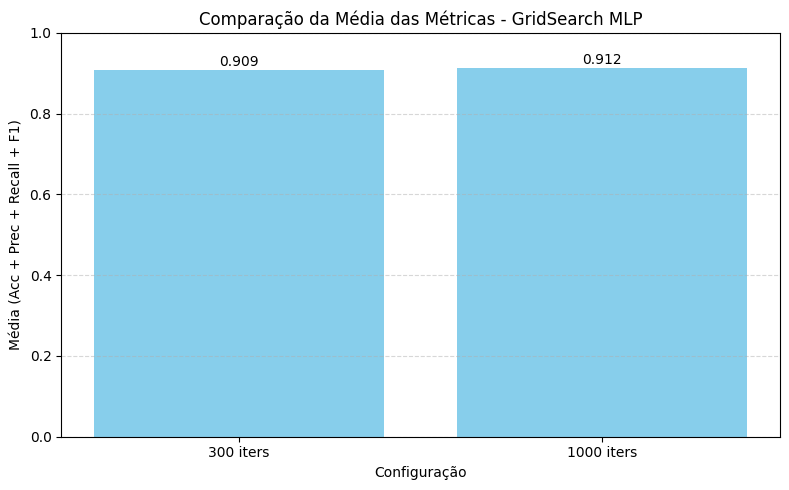

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Parâmetros para testar
param_grid = {
    'hidden_layer_sizes': [(40,)],
    'learning_rate_init': [0.01, 0.05],
    'momentum': [0.5, 0.9]
}

# Guardar os resultados
resultados = []

# Rodar GridSearchCV com diferentes max_iter
for max_iter in [300, 1000]:
    clf = MLPClassifier(solver='adam', max_iter=max_iter)
    grid = GridSearchCV(clf, param_grid, cv=3)
    grid.fit(X_treino, y_treino)

    # Melhor modelo encontrado
    melhor_modelo = grid.best_estimator_
    y_pred = melhor_modelo.predict(X_validacao)

    # Avaliação
    acc = accuracy_score(y_validacao, y_pred)
    prec = precision_score(y_validacao, y_pred, average='macro')
    rec = recall_score(y_validacao, y_pred, average='macro')
    f1 = f1_score(y_validacao, y_pred, average='macro')
    media = (acc + prec + rec + f1) / 4

    resultados.append({
        'max_iter': max_iter,
        'params': grid.best_params_,
        'acc': acc,
        'prec': prec,
        'rec': rec,
        'f1': f1,
        'media': media
    })

# Plotar gráfico
labels = [f"{r['max_iter']} iters" for r in resultados]
medias = [r['media'] for r in resultados]

plt.figure(figsize=(8, 5))
plt.bar(labels, medias, color='skyblue')
plt.title("Comparação da Média das Métricas - GridSearch MLP")
plt.ylabel("Média (Acc + Prec + Recall + F1)")
plt.xlabel("Configuração")
plt.ylim(0, 1)
for i, v in enumerate(medias):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [31]:
clf = MLPClassifier(solver='adam', hidden_layer_sizes=(40), learning_rate_init=0.05, momentum=0.5, verbose=True)
clf.fit(X_treino, y_treino)

y_pred_validacao = clf.predict(X_validacao)

# Exibir as previsões com os rótulos reais
# print("Previsões e Rótulos Reais no Conjunto de Validação:")
# for i in range(len(y_validacao)):
#     print(f"Real: {y_validacao.iloc[i]}, Previsto: {y_pred_validacao[i]}")

# Relatório de desempenho na validação
print("Desempenho na validação:")
print(classification_report(y_validacao, y_pred_validacao))

# Avaliar o modelo nos dados de teste
y_pred_teste = clf.predict(X_teste)

# Relatório de desempenho no teste
print("Desempenho no teste:")
print(classification_report(y_teste, y_pred_teste))

# Acurácia no teste
accuracy = accuracy_score(y_teste, y_pred_teste)
print(f"Acurácia no teste: {accuracy:.2f}")

print(clf.classes_)


Iteration 1, loss = 1.34774782
Iteration 2, loss = 0.94985919
Iteration 3, loss = 0.73536644
Iteration 4, loss = 0.61716776
Iteration 5, loss = 0.55298477
Iteration 6, loss = 0.48599513
Iteration 7, loss = 0.42434050
Iteration 8, loss = 0.38077242
Iteration 9, loss = 0.33960138
Iteration 10, loss = 0.29686194
Iteration 11, loss = 0.26486506
Iteration 12, loss = 0.24807179
Iteration 13, loss = 0.22356748
Iteration 14, loss = 0.21268073
Iteration 15, loss = 0.19380855
Iteration 16, loss = 0.18622596
Iteration 17, loss = 0.17068259
Iteration 18, loss = 0.17955683
Iteration 19, loss = 0.18052725
Iteration 20, loss = 0.17263639
Iteration 21, loss = 0.15700424
Iteration 22, loss = 0.15756108
Iteration 23, loss = 0.12942197
Iteration 24, loss = 0.11689097
Iteration 25, loss = 0.11459850
Iteration 26, loss = 0.12435774
Iteration 27, loss = 0.13122347
Iteration 28, loss = 0.11647866
Iteration 29, loss = 0.11268986
Iteration 30, loss = 0.10698166
Iteration 31, loss = 0.09324519
Iteration 32, los



# Arvore de Decisão

In [32]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score


In [33]:
# Conversão dos valores de string para inteiros
def converter(val):
    if val == 'x':
        return 1
    elif val == 'o':
        return -1
    elif val == 'b':
        return 0
    else:
        return val  # Para manter a classe original (e.g. 'positive' ou 'negative')


In [34]:
# Leitura dos arquivos CSV
treino = pd.read_csv("tictactoe_treino.csv")
teste = pd.read_csv("tictactoe_teste.csv")
validacao = pd.read_csv("tictactoe_validacao.csv")


# Aplicação da função 'converter' nos conjuntos
X_treino = treino.drop('class', axis=1).applymap(converter)
y_treino = treino['class']

X_teste = teste.drop('class', axis=1).applymap(converter)
y_teste = teste['class']

X_validacao = validacao.drop('class', axis=1).applymap(converter)
y_validacao = validacao['class']


<ipython-input-34-832aacf1b8d0>:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_treino = treino.drop('class', axis=1).applymap(converter)
<ipython-input-34-832aacf1b8d0>:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_teste = teste.drop('class', axis=1).applymap(converter)
<ipython-input-34-832aacf1b8d0>:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_validacao = validacao.drop('class', axis=1).applymap(converter)


In [35]:
# Criação e treinamento do classificador (árvore de decisão)
clf = DecisionTreeClassifier(criterion='entropy', random_state=40)
clf.fit(X_treino, y_treino)


DecisionTreeClassifier(criterion='entropy', random_state=40)

In [36]:
y_pred_validacao = clf.predict(X_validacao)

acc_val = accuracy_score(y_validacao, y_pred_validacao)
prec_val = precision_score(y_validacao, y_pred_validacao, average='macro')
rec_val = recall_score(y_validacao, y_pred_validacao, average='macro')
f1_val = f1_score(y_validacao, y_pred_validacao, average='macro')
media_val = (acc_val + prec_val + rec_val + f1_val) / 4

print("=== Avaliação no conjunto de VALIDAÇÃO ===")
print(f"Acurácia: {acc_val:.3f}")
print(f"Precisão: {prec_val:.3f}")
print(f"Recall: {rec_val:.3f}")
print(f"F1-score: {f1_val:.3f}")
print(f"Média das métricas: {media_val:.3f}")
print(classification_report(y_validacao, y_pred_validacao))


=== Avaliação no conjunto de VALIDAÇÃO ===
Acurácia: 0.844
Precisão: 0.842
Recall: 0.844
F1-score: 0.841
Média das métricas: 0.843
                  precision    recall  f1-score   support

          Empate       0.87      1.00      0.93        80
Jogador O venceu       0.82      0.82      0.82        80
Jogador X venceu       0.88      0.84      0.86        80
        Tem jogo       0.79      0.71      0.75        80

        accuracy                           0.84       320
       macro avg       0.84      0.84      0.84       320
    weighted avg       0.84      0.84      0.84       320



In [37]:
y_pred_teste = clf.predict(X_teste)

acc_teste = accuracy_score(y_teste, y_pred_teste)
prec_teste = precision_score(y_teste, y_pred_teste, average='macro')
rec_teste = recall_score(y_teste, y_pred_teste, average='macro')
f1_teste = f1_score(y_teste, y_pred_teste, average='macro')
media_teste = (acc_teste + prec_teste + rec_teste + f1_teste) / 4

print("=== Avaliação no conjunto de TESTE ===")
print(f"Acurácia: {acc_teste:.3f}")
print(f"Precisão: {prec_teste:.3f}")
print(f"Recall: {rec_teste:.3f}")
print(f"F1-score: {f1_teste:.3f}")
print(f"Média das métricas: {media_teste:.3f}")
print(classification_report(y_teste, y_pred_teste))


=== Avaliação no conjunto de TESTE ===
Acurácia: 0.806
Precisão: 0.807
Recall: 0.806
F1-score: 0.803
Média das métricas: 0.806
                  precision    recall  f1-score   support

          Empate       0.83      1.00      0.91        40
Jogador O venceu       0.82      0.78      0.79        40
Jogador X venceu       0.85      0.72      0.78        40
        Tem jogo       0.72      0.72      0.72        40

        accuracy                           0.81       160
       macro avg       0.81      0.81      0.80       160
    weighted avg       0.81      0.81      0.80       160



In [38]:
# Verificação das classes aprendidas
print("Classes aprendidas:", clf.classes_)



Classes aprendidas: ['Empate' 'Jogador O venceu' 'Jogador X venceu' 'Tem jogo']


# Random Forest

In [39]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


In [40]:
def converter(val):
    if val == 'x':
        return 1
    elif val == 'o':
        return -1
    elif val == 'b':
        return 0
    else:
        return val


In [41]:
treino = pd.read_csv("tictactoe_treino.csv")
teste = pd.read_csv("tictactoe_teste.csv")
validacao = pd.read_csv("tictactoe_validacao.csv")

X_treino = treino.drop('class', axis=1).applymap(converter)
y_treino = treino['class']

X_teste = teste.drop('class', axis=1).applymap(converter)
y_teste = teste['class']

X_validacao = validacao.drop('class', axis=1).applymap(converter)
y_validacao = validacao['class']


<ipython-input-41-0041c387beec>:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_treino = treino.drop('class', axis=1).applymap(converter)
<ipython-input-41-0041c387beec>:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_teste = teste.drop('class', axis=1).applymap(converter)
<ipython-input-41-0041c387beec>:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_validacao = validacao.drop('class', axis=1).applymap(converter)


In [42]:
clf = RandomForestClassifier(
    n_estimators=100,
    criterion='entropy',
    max_depth=None,
    random_state=42
)
clf.fit(X_treino, y_treino)


RandomForestClassifier(criterion='entropy', random_state=42)

In [43]:
y_pred_validacao = clf.predict(X_validacao)

acc_val = accuracy_score(y_validacao, y_pred_validacao)
prec_val = precision_score(y_validacao, y_pred_validacao, average='macro')
rec_val = recall_score(y_validacao, y_pred_validacao, average='macro')
f1_val = f1_score(y_validacao, y_pred_validacao, average='macro')
media_val = (acc_val + prec_val + rec_val + f1_val) / 4

print("=== Avaliação no conjunto de VALIDAÇÃO ===")
print(f"Acurácia: {acc_val:.3f}")
print(f"Precisão: {prec_val:.3f}")
print(f"Recall: {rec_val:.3f}")
print(f"F1-score: {f1_val:.3f}")
print(f"Média das métricas: {media_val:.3f}")
print(classification_report(y_validacao, y_pred_validacao))


=== Avaliação no conjunto de VALIDAÇÃO ===
Acurácia: 0.950
Precisão: 0.952
Recall: 0.950
F1-score: 0.949
Média das métricas: 0.950
                  precision    recall  f1-score   support

          Empate       0.98      1.00      0.99        80
Jogador O venceu       0.92      0.99      0.95        80
Jogador X venceu       0.93      0.99      0.96        80
        Tem jogo       0.99      0.82      0.90        80

        accuracy                           0.95       320
       macro avg       0.95      0.95      0.95       320
    weighted avg       0.95      0.95      0.95       320



In [44]:
y_pred_teste = clf.predict(X_teste)

acc_teste = accuracy_score(y_teste, y_pred_teste)
prec_teste = precision_score(y_teste, y_pred_teste, average='macro')
rec_teste = recall_score(y_teste, y_pred_teste, average='macro')
f1_teste = f1_score(y_teste, y_pred_teste, average='macro')
media_teste = (acc_teste + prec_teste + rec_teste + f1_teste) / 4

print("=== Avaliação no conjunto de TESTE ===")
print(f"Acurácia: {acc_teste:.3f}")
print(f"Precisão: {prec_teste:.3f}")
print(f"Recall: {rec_teste:.3f}")
print(f"F1-score: {f1_teste:.3f}")
print(f"Média das métricas: {media_teste:.3f}")
print(classification_report(y_teste, y_pred_teste))


=== Avaliação no conjunto de TESTE ===
Acurácia: 0.925
Precisão: 0.931
Recall: 0.925
F1-score: 0.924
Média das métricas: 0.926
                  precision    recall  f1-score   support

          Empate       0.95      1.00      0.98        40
Jogador O venceu       0.93      0.97      0.95        40
Jogador X venceu       0.84      0.95      0.89        40
        Tem jogo       1.00      0.78      0.87        40

        accuracy                           0.93       160
       macro avg       0.93      0.92      0.92       160
    weighted avg       0.93      0.93      0.92       160



In [45]:
print("Classes aprendidas:", clf.classes_)


Classes aprendidas: ['Empate' 'Jogador O venceu' 'Jogador X venceu' 'Tem jogo']


# XGBoost


In [46]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


In [47]:
class_mapping = {
    'Empate': 0,
    'Jogador O venceu': 1,
    'Jogador X venceu': 2,
    'Tem jogo': 3
}

def converter(val):
    if val == 'x':
        return 1
    elif val == 'o':
        return -1
    elif val == 'b':
        return 0
    else:
        return val


In [48]:
treino = pd.read_csv("tictactoe_treino.csv")
teste = pd.read_csv("tictactoe_teste.csv")
validacao = pd.read_csv("tictactoe_validacao.csv")

X_treino = treino.drop('class', axis=1).applymap(converter)
y_treino = treino['class'].map(class_mapping)

X_teste = teste.drop('class', axis=1).applymap(converter)
y_teste = teste['class'].map(class_mapping)

X_validacao = validacao.drop('class', axis=1).applymap(converter)
y_validacao = validacao['class'].map(class_mapping)


<ipython-input-48-df0432a99fc2>:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_treino = treino.drop('class', axis=1).applymap(converter)
<ipython-input-48-df0432a99fc2>:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_teste = teste.drop('class', axis=1).applymap(converter)
<ipython-input-48-df0432a99fc2>:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_validacao = validacao.drop('class', axis=1).applymap(converter)


In [49]:
clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    objective='multi:softmax',
    num_class=4
)

clf.fit(X_treino, y_treino)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None, num_class=4,
              num_parallel_tree=None, ...)

In [50]:
y_pred_validacao = clf.predict(X_validacao)

acc_val = accuracy_score(y_validacao, y_pred_validacao)
prec_val = precision_score(y_validacao, y_pred_validacao, average='macro')
rec_val = recall_score(y_validacao, y_pred_validacao, average='macro')
f1_val = f1_score(y_validacao, y_pred_validacao, average='macro')
media_val = (acc_val + prec_val + rec_val + f1_val) / 4

print("=== Avaliação no conjunto de VALIDAÇÃO ===")
print(f"Acurácia: {acc_val:.3f}")
print(f"Precisão: {prec_val:.3f}")
print(f"Recall: {rec_val:.3f}")
print(f"F1-score: {f1_val:.3f}")
print(f"Média das métricas: {media_val:.3f}")
print(classification_report(y_validacao, y_pred_validacao))


=== Avaliação no conjunto de VALIDAÇÃO ===
Acurácia: 0.994
Precisão: 0.994
Recall: 0.994
F1-score: 0.994
Média das métricas: 0.994
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        80
           1       1.00      1.00      1.00        80
           2       1.00      0.99      0.99        80
           3       1.00      0.99      0.99        80

    accuracy                           0.99       320
   macro avg       0.99      0.99      0.99       320
weighted avg       0.99      0.99      0.99       320



In [51]:
y_pred_teste = clf.predict(X_teste)

acc_teste = accuracy_score(y_teste, y_pred_teste)
prec_teste = precision_score(y_teste, y_pred_teste, average='macro')
rec_teste = recall_score(y_teste, y_pred_teste, average='macro')
f1_teste = f1_score(y_teste, y_pred_teste, average='macro')
media_teste = (acc_teste + prec_teste + rec_teste + f1_teste) / 4

print("=== Avaliação no conjunto de TESTE ===")
print(f"Acurácia: {acc_teste:.3f}")
print(f"Precisão: {prec_teste:.3f}")
print(f"Recall: {rec_teste:.3f}")
print(f"F1-score: {f1_teste:.3f}")
print(f"Média das métricas: {media_teste:.3f}")
print(classification_report(y_teste, y_pred_teste))


=== Avaliação no conjunto de TESTE ===
Acurácia: 0.988
Precisão: 0.988
Recall: 0.988
F1-score: 0.987
Média das métricas: 0.988
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        40
           1       1.00      1.00      1.00        40
           2       0.97      0.97      0.97        40
           3       1.00      0.97      0.99        40

    accuracy                           0.99       160
   macro avg       0.99      0.99      0.99       160
weighted avg       0.99      0.99      0.99       160



In [52]:
print("Classes aprendidas:", clf.classes_)


Classes aprendidas: [0 1 2 3]
